1. Phenotype layer = summary variables these show convergence across environments
2. Biomass-realization layer  = 5000 biomass producing reactions; shows HOW the cell builds biomass (internal gene expression)
3. Metabolic adaptation layer = exchange reactions etc; environment-response layer

**Understanding biomass types**
* protein = translation
* RNA = transcription
* lipid = post-translation
* prosthetic group = complex formation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# plt.style.use("ggplot")
color_map = sns.color_palette("crest", as_cmap=True)

In [2]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [3]:
df = pd.read_pickle(DATA/'bm_all_samples.pkl')
# df_filtered = df.loc[(df != 0).any(axis=1)]

In [5]:
df.shape

(3823, 7259)

### Sanity checks

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
tol = 1e-19
non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df.columns if c not in non_flux_cols]

In [8]:
tiny_vals = df[flux_cols].stack()
tiny_vals = tiny_vals[(tiny_vals != 0) & (tiny_vals.abs() <= tol)]

print("Number of tiny values:", len(tiny_vals))

Number of tiny values: 1113


In [7]:
print(tiny_vals.head())

28  no3_glyc_sample_63   -3.861484e-41
53  glc_sample_334        9.605950e-20
    glyc_sample_29        8.354200e-20
    glyc_sample_325       5.960435e-20
    glyc_sample_443       1.263455e-20
dtype: float64


In [9]:
df_clean = df.copy()

mask = df_clean[flux_cols].abs() <= tol
df_clean.loc[:, flux_cols] = df_clean[flux_cols].mask(mask, 0)

In [10]:
tiny_vals = df_clean[flux_cols].stack()
tiny_vals = tiny_vals[(tiny_vals != 0) & (tiny_vals.abs() <= tol)]

print("Number of tiny values in clean df:", len(tiny_vals))

Number of tiny values in clean df: 0


# Overview of  reaction activity

In [11]:
df_plot = df_clean[~df_clean["biomass_type"].isin(["mu", "env"])]

active_counts = (df_plot[flux_cols] != 0).sum(axis=1)

/triumvirate/apps/.scratch/celinaha/ipykernel_439250/1834614464.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


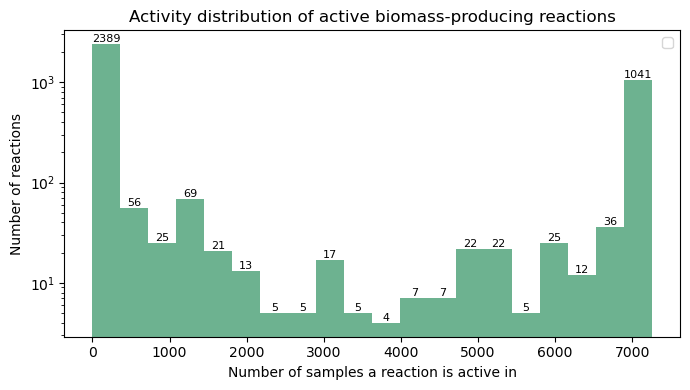

In [ ]:
plt.figure(figsize=(7,4))

counts, bins, patches = plt.hist(active_counts, bins=20, color=color_map(0.20))
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        plt.text(
            (left + right) / 2,   
            count,                
            int(count),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.yscale("log")
plt.xlabel("Number of samples a reaction is active in")
plt.ylabel("Number of reactions")
plt.title("Activity distribution of active biomass-producing reactions")
plt.legend()

plt.tight_layout()
plt.show()

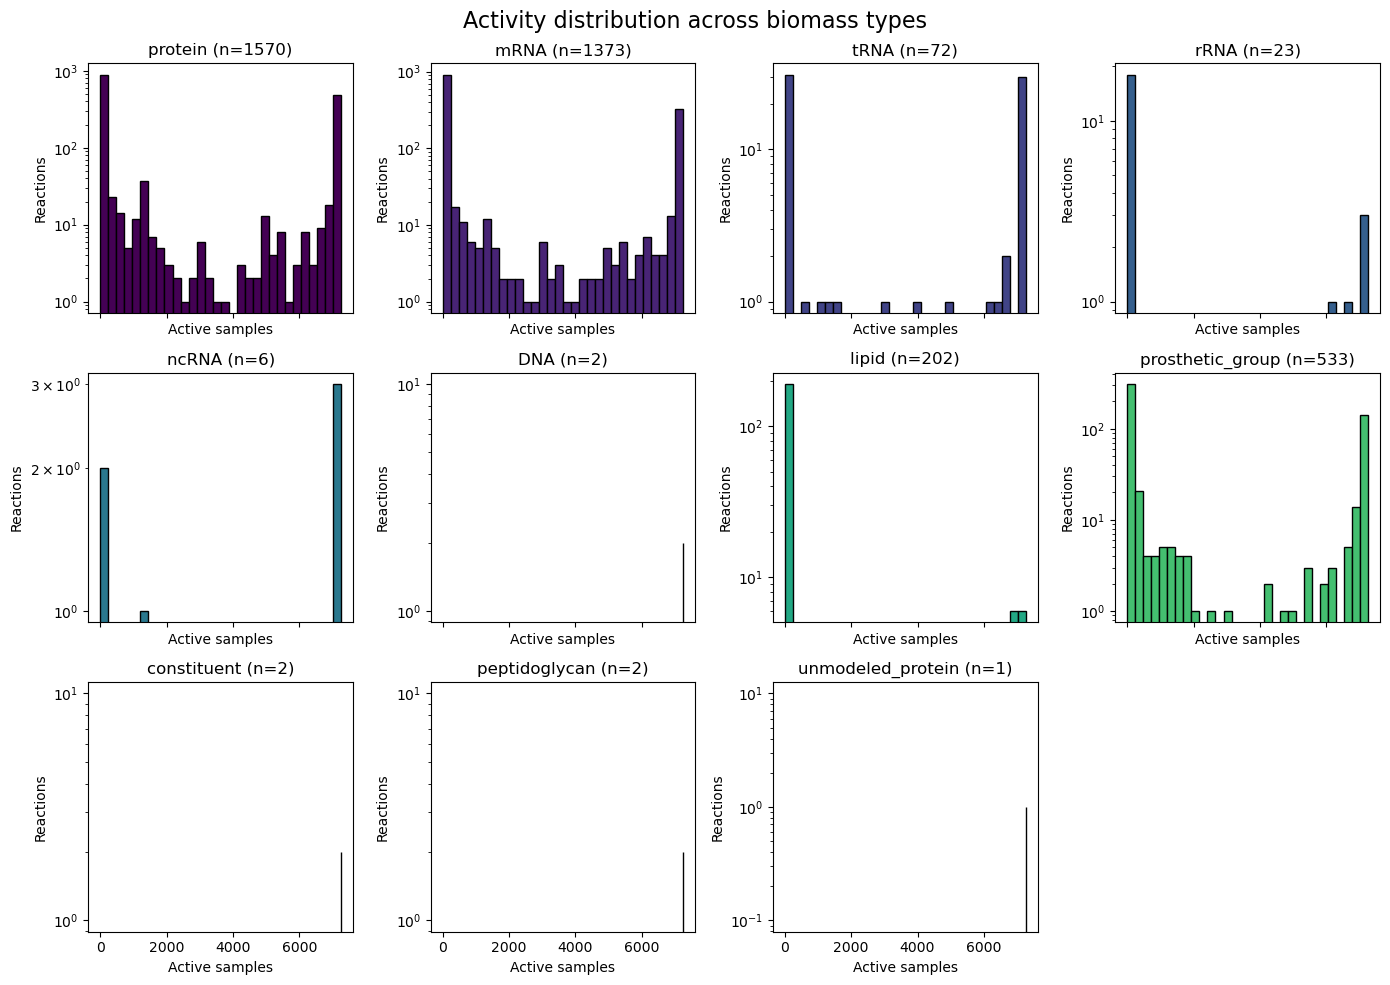

In [ ]:
import math

biomass_types = df_plot["biomass_type"].unique()
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(biomass_types)))

ncols = 4
nrows = math.ceil(len(biomass_types) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10), sharex=True)
axes = axes.flatten()

threshold = 15

for ax, btype, color in zip(axes, biomass_types, colors):
    sub_df = df_plot[df_plot["biomass_type"] == btype]

    reaction_data = sub_df.drop(columns=["biomass_type"])

    active_counts = (reaction_data != 0).sum(axis=1)

    ax.hist(active_counts, bins=30, color=color, edgecolor="black")
    # ax.axvline(threshold, linestyle="--", color="red", linewidth=1)

    ax.set_yscale("log")  
    ax.set_title(f"{btype} (n={len(active_counts)})")
    ax.set_xlabel("Active samples")
    ax.set_ylabel("Reactions")

for ax in axes[len(biomass_types):]:
    fig.delaxes(ax)

fig.suptitle("Activity distribution across biomass types", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_glyc']

sample_cols = [c for c in df_plot.columns if '_sample_' in c]
sources = pd.Series(sample_cols, index=sample_cols).str.split('_sample_').str[0]

present = df_plot[sample_cols]>0      

by_source_any = present.T.groupby(sources).any().T

counts = by_source_any.groupby(df_plot['biomass_type']).sum()
counts = counts.reindex(columns=env_order)

counts

,glc,ac,lcts,glyc,succ,arg_glc,arg_ac,arg_glyc,nh4_glc,nh4_ac,no3_glc,no3_glyc
biomass_type,,,,,,,,,,,,
DNA,2,2,2,2,2,2,2,2,2,2,2,2
constituent,2,2,2,2,2,2,2,2,2,2,2,2
lipid,24,19,18,30,25,24,30,25,24,30,24,29
mRNA,467,436,450,446,449,446,442,450,473,429,446,453
ncRNA,4,3,4,4,4,3,4,4,4,4,3,4
peptidoglycan,2,2,2,2,2,2,2,2,2,2,2,2
prosthetic_group,223,227,218,222,227,212,225,225,222,219,218,225
protein,683,646,660,660,663,651,652,665,690,630,664,676
rRNA,5,5,5,5,6,6,6,6,6,10,6,6


## Removing reactions with low activity (< 50 counts) and constant activity

In [13]:
df_no_env = df_clean.loc[df_clean["biomass_type"] != "env"]
mu_row = df_no_env.loc[df_no_env["biomass_type"] == "mu"]
df_no_env_no_mu = df_no_env.loc[df_no_env["biomass_type"] != "mu"]

active_counts = (df_no_env_no_mu != 0).sum(axis=1)

max_samples = df.shape[1]

df_filtered = df_no_env_no_mu.loc[
    (active_counts >= 50) &
    (active_counts < 0.99 * max_samples)
]

df_filtered = pd.concat([df_filtered, mu_row])

In [14]:
non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df_filtered.columns if c not in non_flux_cols]

In [15]:
tiny_mask = (df_filtered[flux_cols].abs() > 0) & (df_filtered[flux_cols].abs() <= tol)
tiny_cols = tiny_mask.columns[tiny_mask.any(axis=0)]
tiny_cols

Index([], dtype='str')

**Which reactions vary most:**

In [16]:
# variance = df_filtered.select_dtypes(include="number").var(axis=1)

df_no_mu = df_filtered[df_filtered["biomass_type"] != "mu"].copy()

non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df_no_mu.columns if c not in non_flux_cols]

variance = df_no_mu[flux_cols].var(axis=1)
top_var = variance.sort_values(ascending=False).head(31)

In [17]:
df_filtered["variance"] = variance

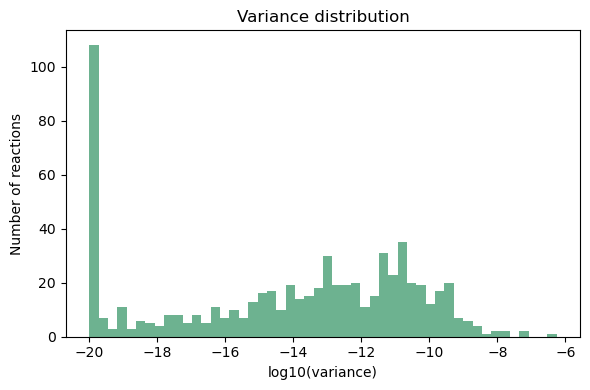

In [17]:
plt.figure(figsize=(6,4))
plt.hist(np.log10(variance + 1e-20), bins=50, color=color_map(0.20))
plt.xlabel("log10(variance)")
plt.ylabel("Number of reactions")
plt.title("Variance distribution")
plt.tight_layout()
plt.show()

In [28]:
variance.describe()

count    6.540000e+02
mean     1.134832e-09
std      2.185563e-08
min      2.603624e-37
25%      7.887436e-18
50%      4.642100e-14
75%      7.574629e-12
max      5.544535e-07
dtype: float64

**components driving variance**

In [18]:
high_var = df_filtered[df_filtered["variance"] >= variance.quantile(0.9)]
high_var["biomass_type"].value_counts()

biomass_type
protein             56
prosthetic_group     7
lipid                3
Name: count, dtype: int64

**distribution per biomass type**

In [17]:
# df_plot = df_filtered[df_filtered["biomass_type"] != "mu"].copy()
df_plot = df_filtered.drop(columns=["reaction", "variance"], errors="ignore")
df_plot = df_plot[:-1]

df_long = df_plot.melt(
    id_vars="biomass_type",
    var_name="sample",
    value_name="flux"
)

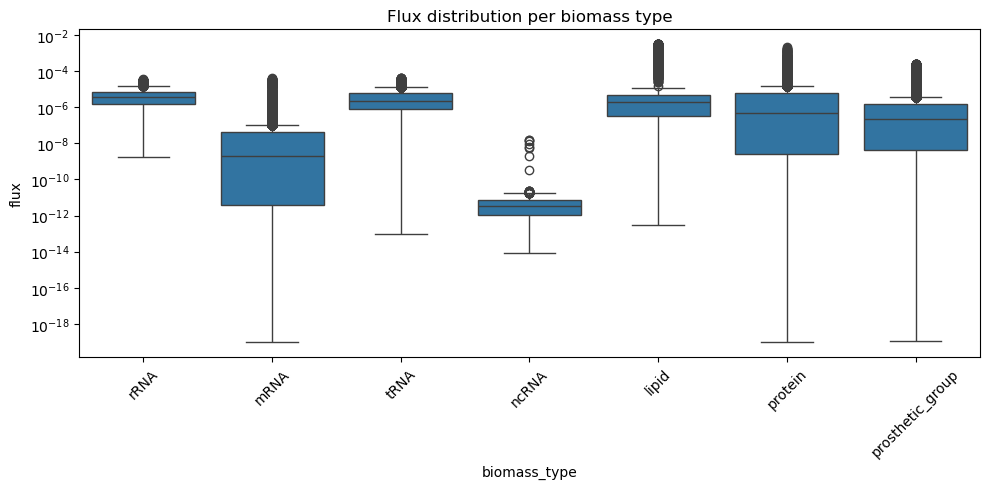

In [20]:
df_long = df_long[df_long["flux"] > 0]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_long,
    x="biomass_type",
    y="flux"
)

plt.xticks(rotation=45)
plt.yscale('log')
plt.title("Flux distribution per biomass type")
plt.tight_layout()
plt.show()

In [18]:
df_filtered['biomass_type'].value_counts()

biomass_type
protein             300
mRNA                197
prosthetic_group    123
lipid                18
tRNA                 13
rRNA                  2
ncRNA                 1
mu                    1
Name: count, dtype: int64

In [19]:
df_filtered[df_filtered['biomass_type']=='ncRNA']

,reaction,biomass_type,glc_sample_0,glc_sample_1,glc_sample_2,glc_sample_3,glc_sample_4,glc_sample_5,glc_sample_6,glc_sample_7,...,no3_glyc_sample_587,no3_glyc_sample_588,no3_glyc_sample_589,no3_glyc_sample_590,no3_glyc_sample_591,no3_glyc_sample_592,no3_glyc_sample_593,no3_glyc_sample_594,no3_glyc_sample_595,variance
1478,transcription_TU482_with_TERM161_from_RpoD_mon...,ncRNA,5.523405e-14,0.0,0.0,0.0,0.0,8.431024e-13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.116937e-19


**Which reactions are less correlated with growth**

In [19]:
df_corr = df_filtered.set_index("reaction")
mu = df_corr.loc["biomass_dilution"]

reaction_data = df_corr.drop(index="biomass_dilution")
reaction_data = reaction_data.drop(columns=["biomass_type"], errors="ignore")
corr = reaction_data.T.corrwith(mu, method="spearman")

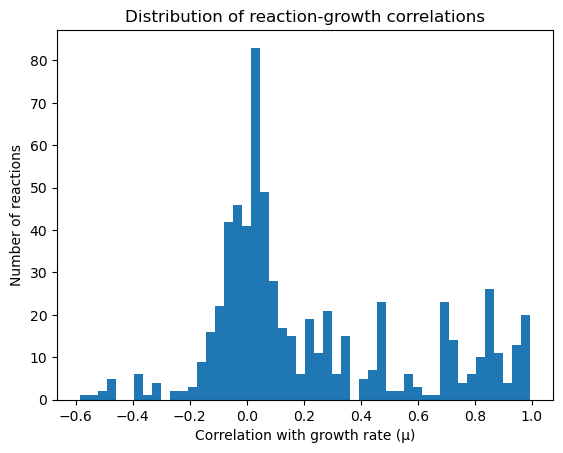

In [25]:
plt.hist(corr, bins=50)
plt.xlabel("Correlation with growth rate (μ)")
plt.ylabel("Number of reactions")
plt.title("Distribution of reaction-growth correlations")
plt.show()

In [20]:
low_corr_mask = corr.abs() < 0.5
low_corr = reaction_data.loc[low_corr_mask]

In [21]:
low_corr_T = low_corr.T

In [22]:
low_corr_T["source"] = low_corr_T.index.str.split("_sample_").str[0]

In [24]:
low_corr_T['source'].value_counts()

source
lcts        786
glc         703
no3_glc     689
nh4_glc     685
arg_glc     667
arg_glyc    653
no3_glyc    596
arg_ac      583
glyc        580
succ        509
ac          482
nh4_ac      291
no3_ac       33
variance      1
Name: count, dtype: int64

## Combining variance and growth corr analyses:

In [23]:
df_no_mu["corr_with_mu"] = corr.values
corr_list = df_no_mu["corr_with_mu"].tolist()
corr_list = corr_list + [1.0]

In [24]:
df_filtered["corr_with_mu"] = corr_list

In [25]:
interesting = df_filtered[
    (df_filtered["variance"] >= variance.quantile(0.9)) &
    (df_filtered["corr_with_mu"].abs() < 0.5)
]

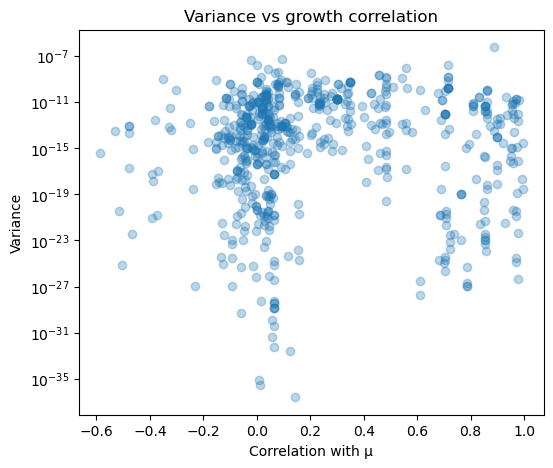

In [34]:
plt.figure(figsize=(6,5))
plt.scatter(df_filtered["corr_with_mu"], df_filtered["variance"], alpha=0.3)
plt.xlabel("Correlation with μ")
# plt.xscale('log')
plt.yscale('log')
plt.ylabel("Variance")
plt.title("Variance vs growth correlation")
plt.show()

**Looking at absolute max and min values of each component, excluding the summary variables**

In [26]:
non_flux_cols = ["reaction", "biomass_type"]
df_clean2 = df_clean[~df_clean["reaction"].str.contains("biomass_to_biomass")].copy()
flux_cols = [c for c in df_clean2.columns if c not in non_flux_cols]

df_long = df_clean2.melt(
    id_vars=["reaction", "biomass_type"],
    value_vars=flux_cols,
    var_name="sample",
    value_name="flux"
)

In [27]:
# df_long_nonzero = df_long[df_long["flux"] != 0]
df_long["abs_flux"] = df_long["flux"].abs()

df_long_nonzero = df_long[df_long["abs_flux"] > 0]

In [28]:
summary = df_long_nonzero.groupby("biomass_type")["abs_flux"].agg(["min", "max"])
summary["log10_min"] = np.log10(summary["min"])
summary["log10_max"] = np.log10(summary["max"])
summary["log10_range"] = summary["log10_max"] - summary["log10_min"]

### Inspecting interesting reactions

In [29]:
interesting_rxns = interesting[['reaction', 'biomass_type']]

In [30]:
meta_cols = ["reaction", "biomass_type"]
sample_cols = [c for c in interesting.columns if c not in meta_cols]

sources = pd.Series(sample_cols, index=sample_cols).str.split("_sample_").str[0]
activity_per_source = pd.DataFrame(index=interesting.index)

for source in sources.unique():
    cols = sources[sources == source].index
    activity_per_source[source] = (interesting[cols] != 0).sum(axis=1)

# Optional: add identifiers back
activity_per_source = pd.concat(
    [interesting[["reaction", "biomass_type"]], activity_per_source],
    axis=1
)

# activity_per_source.head()

In [31]:
activity_per_source.drop(columns=['variance', 'corr_with_mu'], inplace=True)

In [32]:
activity_per_source['variance']=interesting['variance']
activity_per_source['corr_with_mu']=interesting['corr_with_mu']

In [ ]:
# activity_per_source.to_excel(DATA/'interesting_bm_rxns.xlsx')

## PCA

In [33]:
source_counts = low_corr_T["source"].value_counts()

In [34]:
activity_fraction = activity_per_source.drop(columns=['variance', 'corr_with_mu']).copy()

for col in source_counts.index:
    if col in activity_fraction.columns:
        activity_fraction[col] = activity_fraction[col] / source_counts[col]

In [35]:
interesting_idx = interesting.drop(columns=['variance', 'corr_with_mu']).set_index("reaction")
activity_idx = activity_fraction.set_index("reaction")


meta_cols = ["biomass_type"]
sample_cols = [c for c in interesting_idx.columns if c not in meta_cols]


sample_sources = pd.Series(sample_cols, index=sample_cols).str.split("_sample_").str[0]
activity_binary = (interesting_idx[sample_cols] != 0).astype(int)
weighted = activity_binary.copy()

for sample in sample_cols:
    source = sample_sources[sample]
    weighted[sample] = activity_binary[sample] * activity_idx[source]


weighted["biomass_type"] = interesting_idx["biomass_type"]
weighted = weighted.reset_index()

/triumvirate/apps/.scratch/celinaha/ipykernel_1378384/4161961170.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weighted["biomass_type"] = interesting_idx["biomass_type"]
/triumvirate/apps/.scratch/celinaha/ipykernel_1378384/4161961170.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weighted = weighted.reset_index()


In [36]:
sample = "glc_sample_0"
source = sample.split("_sample_")[0]

check = pd.DataFrame({
    "original": interesting_idx[sample],
    "weight": activity_idx[source],
    "weighted": weighted.set_index("reaction")[sample]
})

check.head()

,original,weight,weighted
reaction,,,
b1677_lipid_modification_pg181_p_pe160,0.000000e+00,0.000000,0.000000
b1677_lipid_modification_pg180_p_pe160,0.000000e+00,0.012802,0.000000
translation_b0123,0.000000e+00,0.731152,0.000000
translation_b0720,3.558155e-08,1.000000,1.000000
translation_b0721,4.869491e-14,0.806543,0.806543


In [37]:
weighted_idx = weighted.set_index("reaction")
X = weighted_idx[sample_cols].T
# X["source"] = X.index.str.split("_sample_").str[0]
X["source"] = X.index.str.split("_sample_").str[0]

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = X.drop(columns="source")

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=10)
scores = pca.fit_transform(features)

Text(0.5, 1.0, 'PCA explained variance')

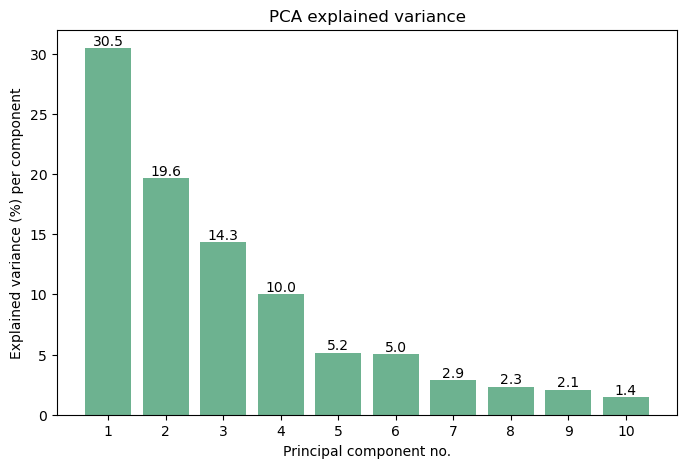

In [42]:
variance = pca.explained_variance_ratio_
components = 1 + np.arange(len(variance))

plt.figure(figsize=(8,5))
bar = plt.bar(components, variance*100, color=color_map(0.2))
plt.bar_label(bar, fmt="{:.1f}")
plt.xticks(components)
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
plt.title('PCA explained variance')
# sns.despine()

In [43]:
df_pca = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "PC3": scores[:, 2],
    "PC4": scores[:, 3],
    "source": X["source"].values
})

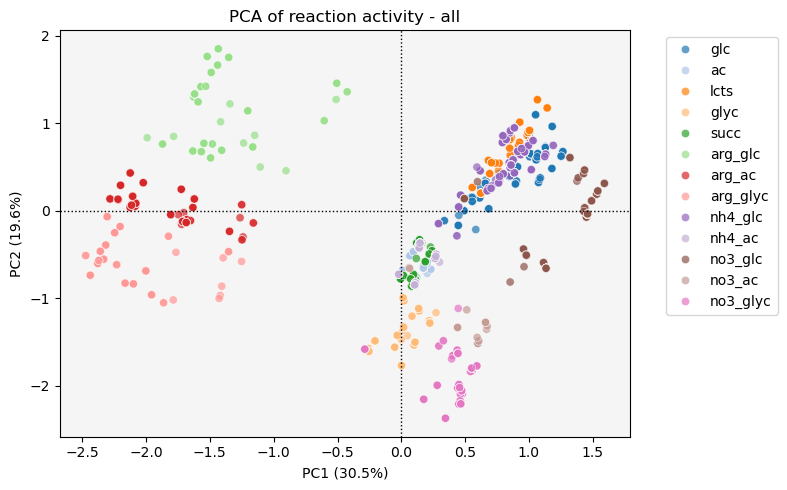

In [44]:
plt.figure(figsize=(8,5))

ax= sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="source",
    palette="tab20",
    alpha=0.7
    )

ax.set_facecolor('whitesmoke')

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"PCA of reaction activity - all")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [45]:
loadings = pd.DataFrame(
    pca.components_.T[:, :4],
    index=features.columns,
    columns=["PC1", "PC2","PC3", "PC4"]
)

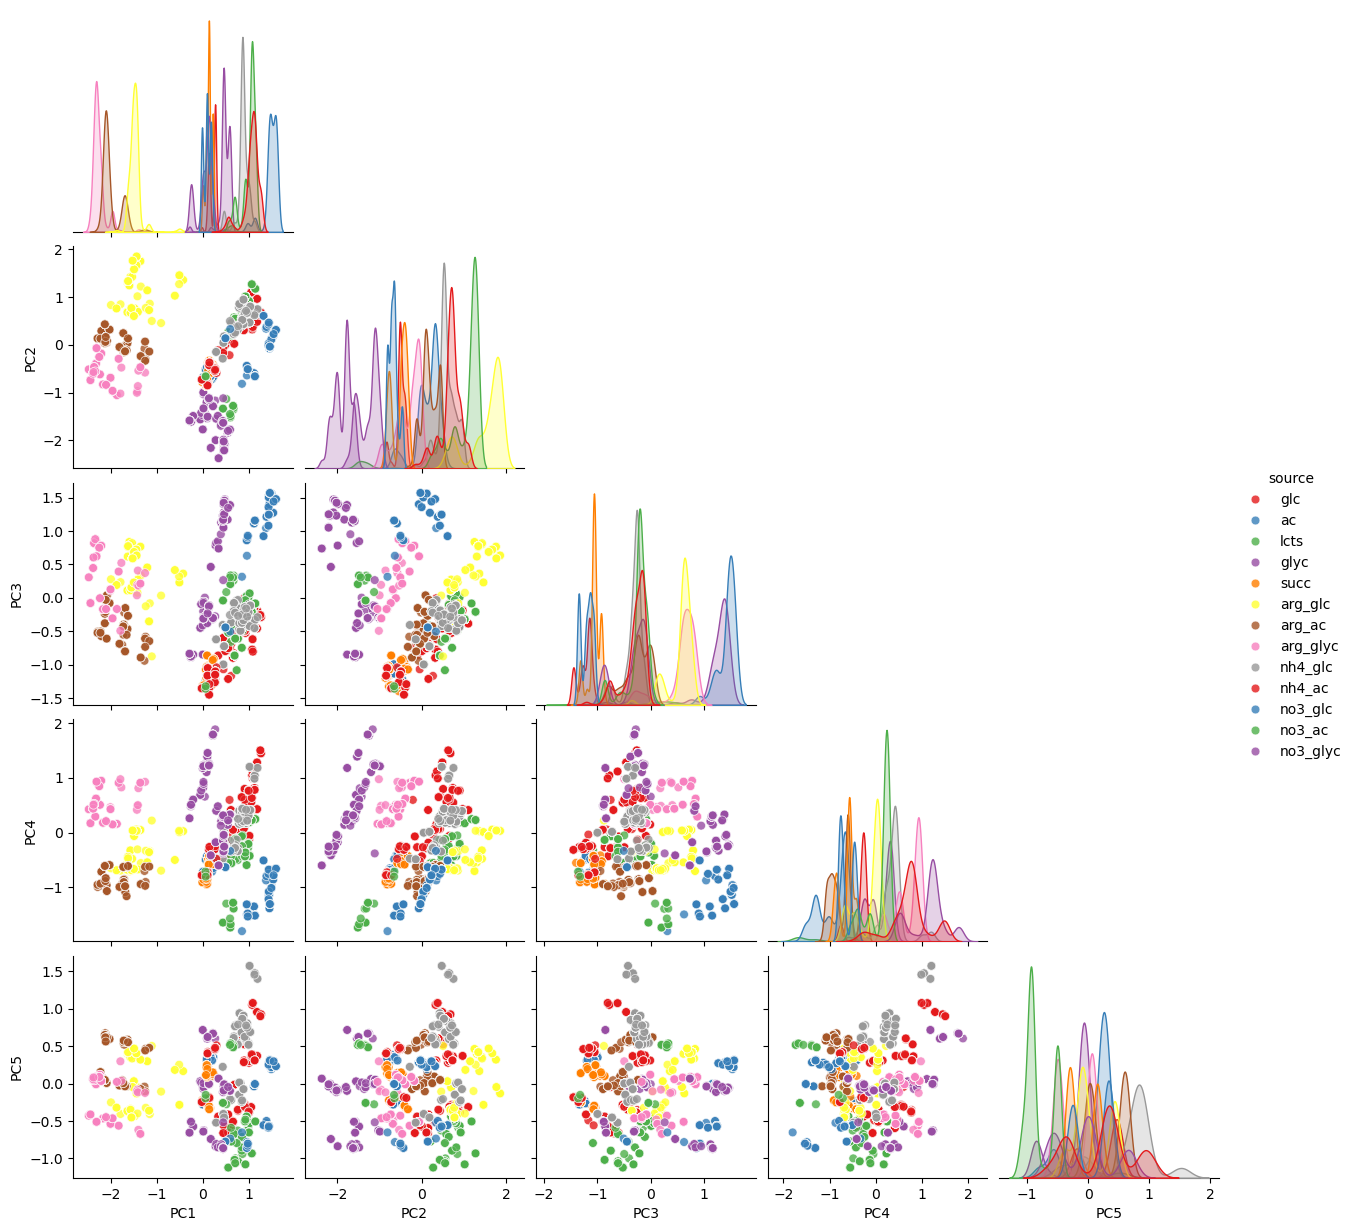

In [ ]:
scores_df = pd.DataFrame(
    scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)]
)

scores_df["source"] = X["source"].values

sns.pairplot(
    scores_df,
    hue="source",
    palette="Set1",
    corner=True,
    plot_kws={"s": 40, "alpha": 0.8}
)

plt.show()

In [ ]:
import plotly.express as px
palette = sns.color_palette("Set1", n_colors=df_pca["source"].nunique()).as_hex()

fig = px.scatter_3d(
    df_pca, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    opacity=0.6,
    color_discrete_sequence=palette,
    color = X['source'],
    # title='Interactive 3D PCA of Biomass Components',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]:.1%})'
    }
)

fig.update_traces(marker=dict(size=4))
fig.show()

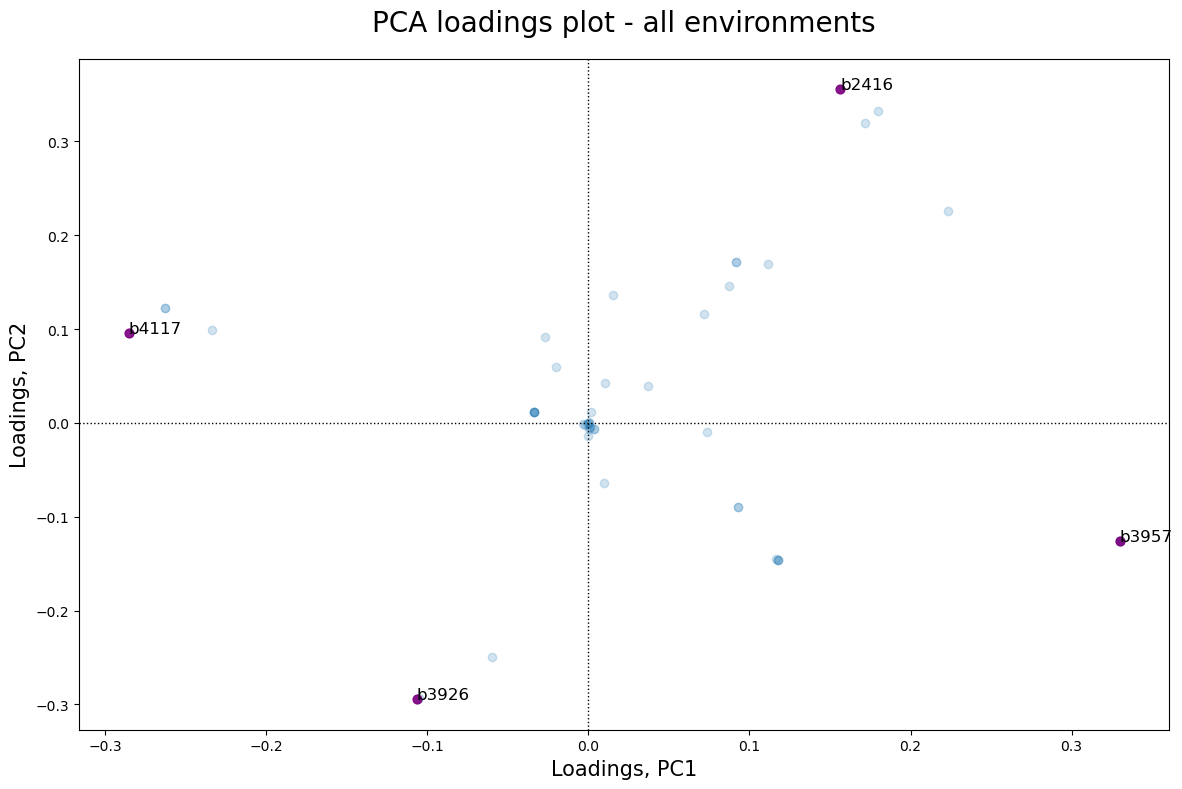

In [ ]:
n = 1  
pc1 = loadings.iloc[:, 0]
pc2 = loadings.iloc[:, 1]

extreme_idx = set()

for pc in [pc1, pc2]:
    extreme_idx.update(pc.nlargest(n).index)
    extreme_idx.update(pc.nsmallest(n).index)

extreme_idx = list(extreme_idx)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(pc1, pc2, alpha=0.2)


ax.scatter(
    pc1.loc[extreme_idx],
    pc2.loc[extreme_idx],
    alpha=0.9,
    s=40,
    color="purple"
)


for variable in extreme_idx:
    label = variable.replace("translation_", "")
    ax.text(
        pc1.loc[variable],
        pc2.loc[variable],
        label,
        fontsize=12
    )

ax.axhline(0, ls=":", c="k", lw=1)
ax.axvline(0, ls=":", c="k", lw=1)

ax.set_xlabel("Loadings, PC1", fontsize=15)
ax.set_ylabel("Loadings, PC2", fontsize=15)

# sns.despine()
plt.title('PCA loadings plot - all environments', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

## PCA by environment:

In [57]:
# nitrogen_sources = ["nh4", "no3", "arg"]
nitrogen_sources = ["nh4_glc", "nh4_ac", 
                    "no3_glc", "no3_glyc", 
                    "arg_glc", "arg_ac", "arg_glyc"]



In [58]:
X["source_type"] = np.where(
    X["source"].isin(nitrogen_sources),
    "n",   # if in nitrogen_sources
    "c"    # otherwise
)

In [59]:
carbon = X[X['source_type']=='c']
nitrogen=X[X['source_type']=='n']

In [60]:
features_c = carbon.drop(columns=["source", "source_type"])
features_n = nitrogen.drop(columns=["source", "source_type"])

pca_c = PCA(n_components=10)
scores_c = pca_c.fit_transform(features_c)

pca_n = PCA(n_components=10)
scores_n = pca_n.fit_transform(features_n)

In [61]:
df_pca_c = pd.DataFrame({
    "PC1": scores_c[:, 0],
    "PC2": scores_c[:, 1],
    "PC3": scores_c[:, 2],
    "source": carbon["source"].values
})


df_pca_n = pd.DataFrame({
    "PC1": scores_n[:, 0],
    "PC2": scores_n[:, 1],
    "PC3": scores_n[:, 2],
    "source": nitrogen["source"].values
})

In [62]:
loadings_c = pd.DataFrame(
    pca_c.components_.T[:, :3],
    index=features_c.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings_n = pd.DataFrame(
    pca_n.components_.T[:, :3],
    index=features_n.columns,
    columns=["PC1", "PC2", "PC3"]
)

Text(0.5, 1.0, 'PCA explained variance - carbon')

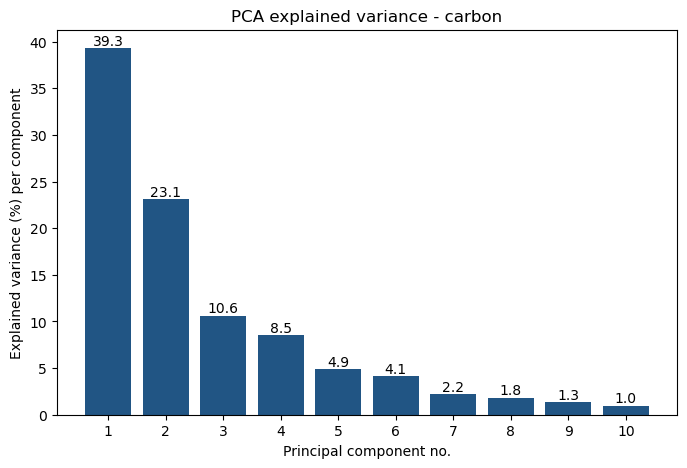

In [52]:
variance_c = pca_c.explained_variance_ratio_
components_c = 1 + np.arange(len(variance_c))

plt.figure(figsize=(8,5))
bar = plt.bar(components_c, variance_c*100, color=color_map(0.80))
plt.bar_label(bar, fmt="{:.1f}")
plt.xticks(components)
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
plt.title('PCA explained variance - carbon')
# sns.despine()

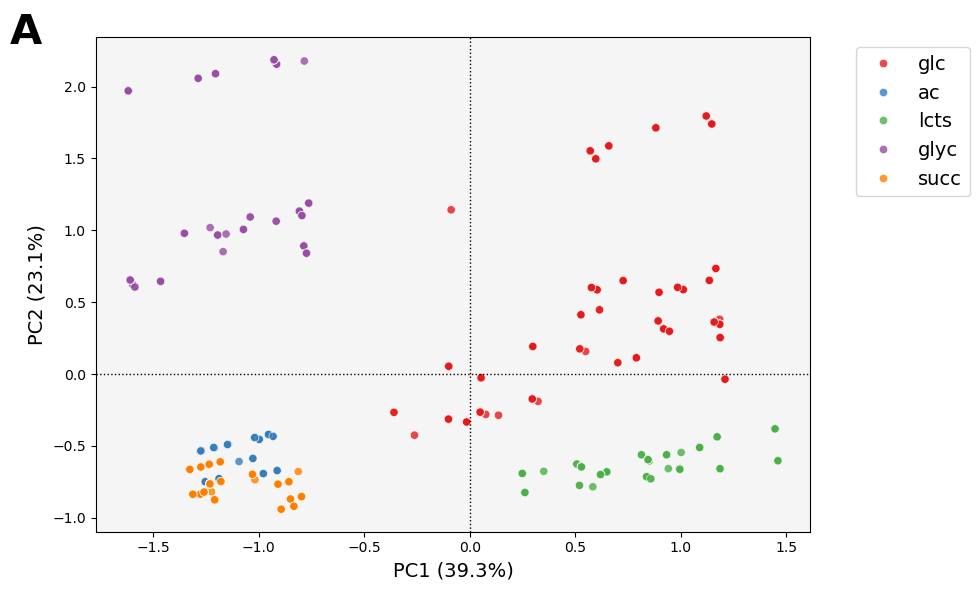

In [56]:
plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data=df_pca_c,
    x="PC1",
    y="PC2",
    hue="source",
    palette="Set1",
    alpha=0.8
)

ax.set_facecolor('whitesmoke')

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)

plt.title(r"PCA of reaction activity - carbon", color="white", fontsize=18)
plt.xlabel(f"PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)", fontsize=14)
plt.ylabel(f"PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)", fontsize=14)

ax.text(-0.12, 1.05, "A", transform=ax.transAxes, fontsize=30, fontweight="bold", va="top", ha="left")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
plt.tight_layout()
plt.show()

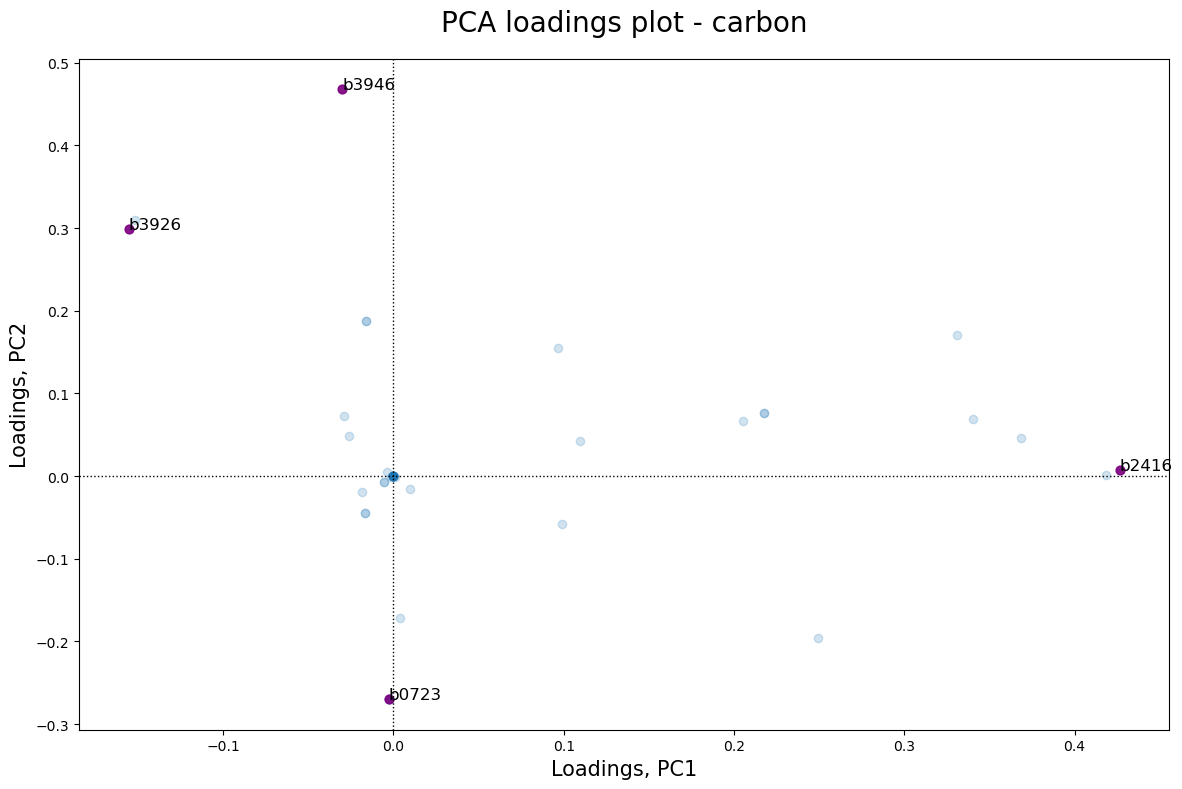

In [ ]:
n = 1  
pc1 = loadings_c.iloc[:, 0]
pc2 = loadings_c.iloc[:, 1]

extreme_idx = set()

for pc in [pc1, pc2]:
    extreme_idx.update(pc.nlargest(n).index)
    extreme_idx.update(pc.nsmallest(n).index)

extreme_idx = list(extreme_idx)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(pc1, pc2, alpha=0.2)

ax.scatter(
    pc1.loc[extreme_idx],
    pc2.loc[extreme_idx],
    alpha=0.9,
    s=40,
    color="purple"
)


for variable in extreme_idx:
    label = variable.replace("translation_", "")
    ax.text(
        pc1.loc[variable],
        pc2.loc[variable],
        label,
        fontsize=12
    )

ax.axhline(0, ls=":", c="k", lw=1)
ax.axvline(0, ls=":", c="k", lw=1)

ax.set_xlabel("Loadings, PC1", fontsize=15)
ax.set_ylabel("Loadings, PC2", fontsize=15)

# sns.despine()
plt.title('PCA loadings plot - carbon', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

/triumvirate/apps/.scratch/celinaha/ipykernel_1378384/1397493029.py:6: UserWarning: The palette list has more values (9) than needed (7), which may not be intended.
  ax = sns.scatterplot(


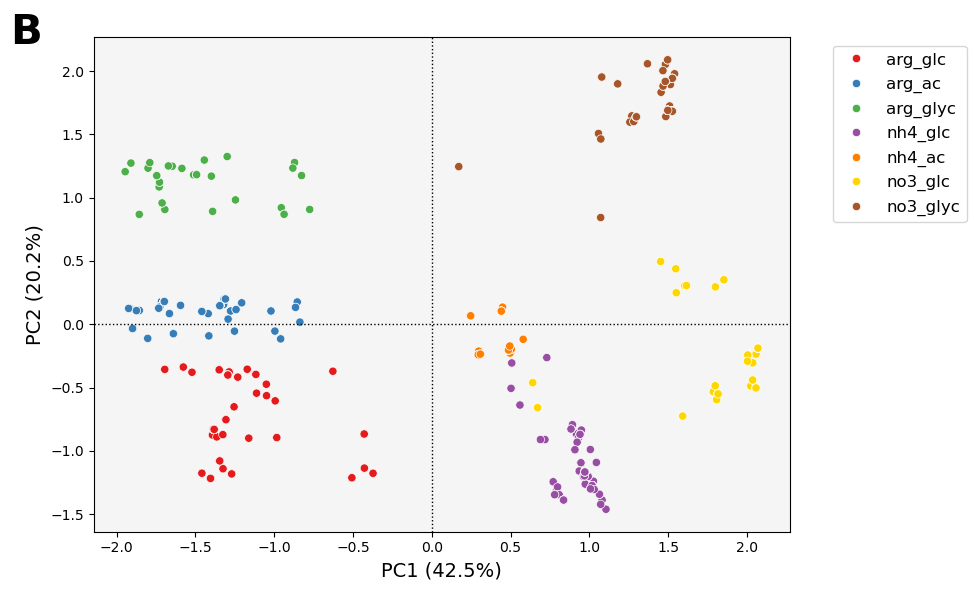

In [64]:
palette = sns.color_palette("Set1", n_colors=9)
palette[5] = "gold"

plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data=df_pca_n,
    x="PC1",
    y="PC2",
    hue="source",
    palette=palette,
    alpha=1.0
)

ax.set_facecolor('whitesmoke')
plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"PCA of reaction activity- nitrogen", color="white", fontsize=18)
plt.xlabel(f"PC1 ({pca_n.explained_variance_ratio_[0]*100:.1f}%)", fontsize=14)
plt.ylabel(f"PC2 ({pca_n.explained_variance_ratio_[1]*100:.1f}%)", fontsize=14)

ax.text(-0.12, 1.05, "B", transform=ax.transAxes, fontsize=30, fontweight="bold", va="top", ha="left")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'PCA explained variance - nitrogen')

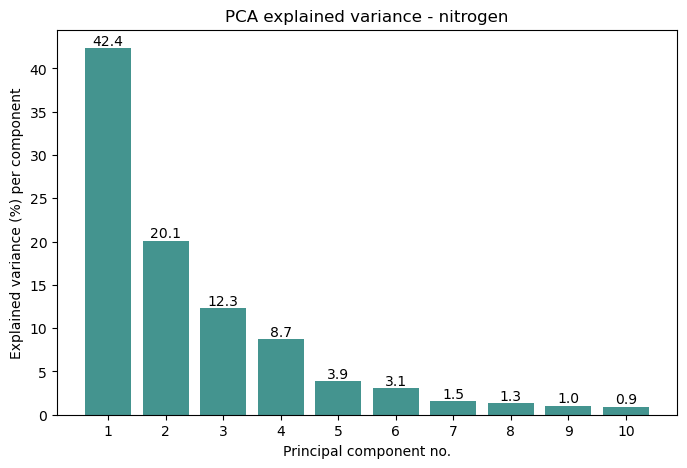

In [98]:
variance_n = pca_n.explained_variance_ratio_
components_n = 1 + np.arange(len(variance_n))

plt.figure(figsize=(8,5))
bar = plt.bar(components_n, variance_n*100, color=color_map(0.40))
plt.bar_label(bar, fmt="{:.1f}")
plt.xticks(components)
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
plt.title('PCA explained variance - nitrogen')
# sns.despine()

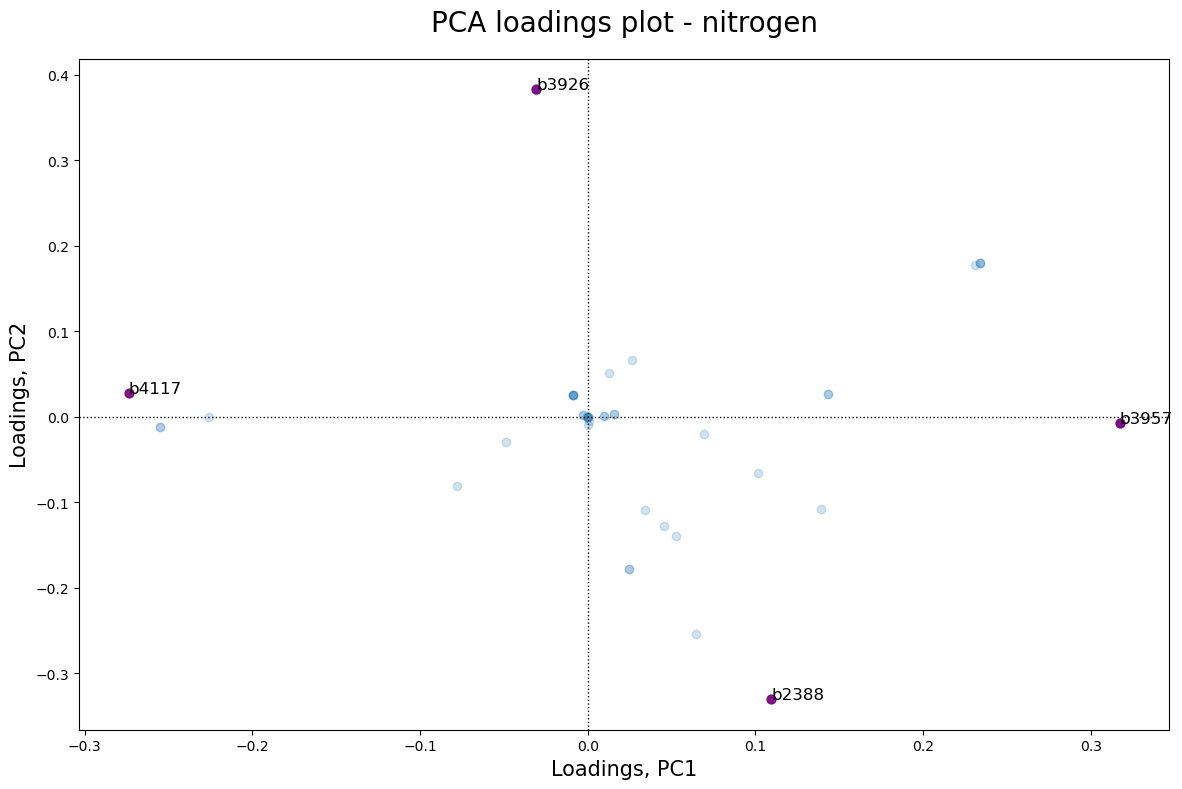

In [ ]:
n = 1  

pc1 = loadings_n.iloc[:, 0]
pc2 = loadings_n.iloc[:, 1]

extreme_idx = set()

for pc in [pc1, pc2]:
    extreme_idx.update(pc.nlargest(n).index)
    extreme_idx.update(pc.nsmallest(n).index)

extreme_idx = list(extreme_idx)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(pc1, pc2, alpha=0.2)


ax.scatter(
    pc1.loc[extreme_idx],
    pc2.loc[extreme_idx],
    alpha=0.9,
    s=40,
    color="purple"
)


for variable in extreme_idx:
    label = variable.replace("translation_", "")
    ax.text(
        pc1.loc[variable],
        pc2.loc[variable],
        label,
        fontsize=12
    )

ax.axhline(0, ls=":", c="k", lw=1)
ax.axvline(0, ls=":", c="k", lw=1)

ax.set_xlabel("Loadings, PC1", fontsize=15)
ax.set_ylabel("Loadings, PC2", fontsize=15)

# sns.despine()
plt.title('PCA loadings plot - nitrogen', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

## Interesting reactions vs uptake etc.:

**CueO, nhd, formation_NADH-DHII-MONOMER_mod_mg2_mod_cu_mod_fad**

In [101]:
active_ndh = activity_binary.columns[activity_binary.loc["translation_b1109"] == 1]

oxygen = df_clean[df_clean['reaction']=='EX_o2_e']
cueO = df_clean[df_clean['reaction']=='translation_b0123']
nadh_d2 = df_clean[df_clean['reaction']=='formation_NADH-DHII-MONOMER_mod_mg2_mod_cu_mod_fad']
cu = df_clean[df_clean['reaction']=='EX_cu2_e']
ndh = df_clean[df_clean['reaction']=='translation_b1109']

In [73]:
cols_drop = ['biomass_type', 'reaction']

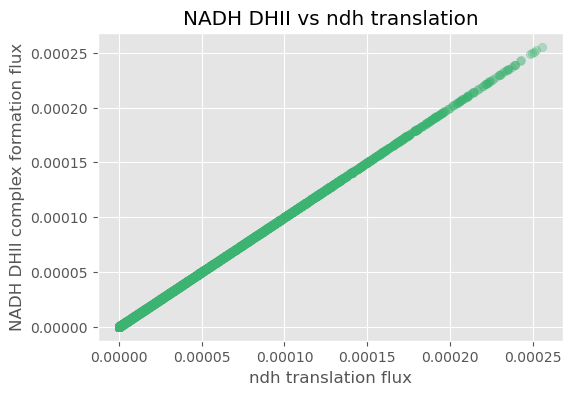

In [199]:
plt.figure(figsize=(6,4))
plt.scatter(ndh.drop(columns=cols_drop), nadh_d2.drop(columns=cols_drop),alpha=0.3, color='mediumseagreen')
plt.xlabel("ndh translation flux")
plt.ylabel("NADH DHII complex formation flux")
plt.title("NADH DHII vs ndh translation")
plt.show()

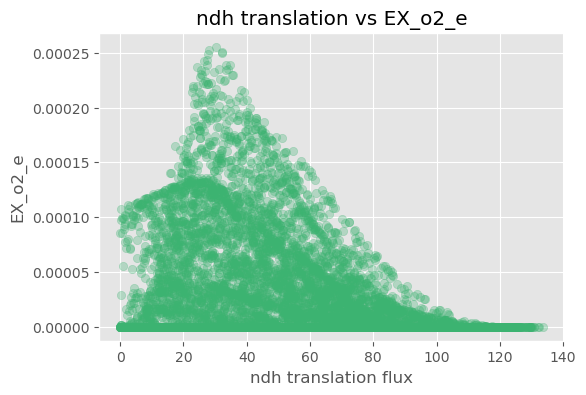

In [200]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen.drop(columns=cols_drop),ndh.drop(columns=cols_drop), alpha=0.3, color='mediumseagreen')
plt.xlabel("ndh translation flux")
plt.ylabel("EX_o2_e")
plt.title("ndh translation vs EX_o2_e")
plt.show()

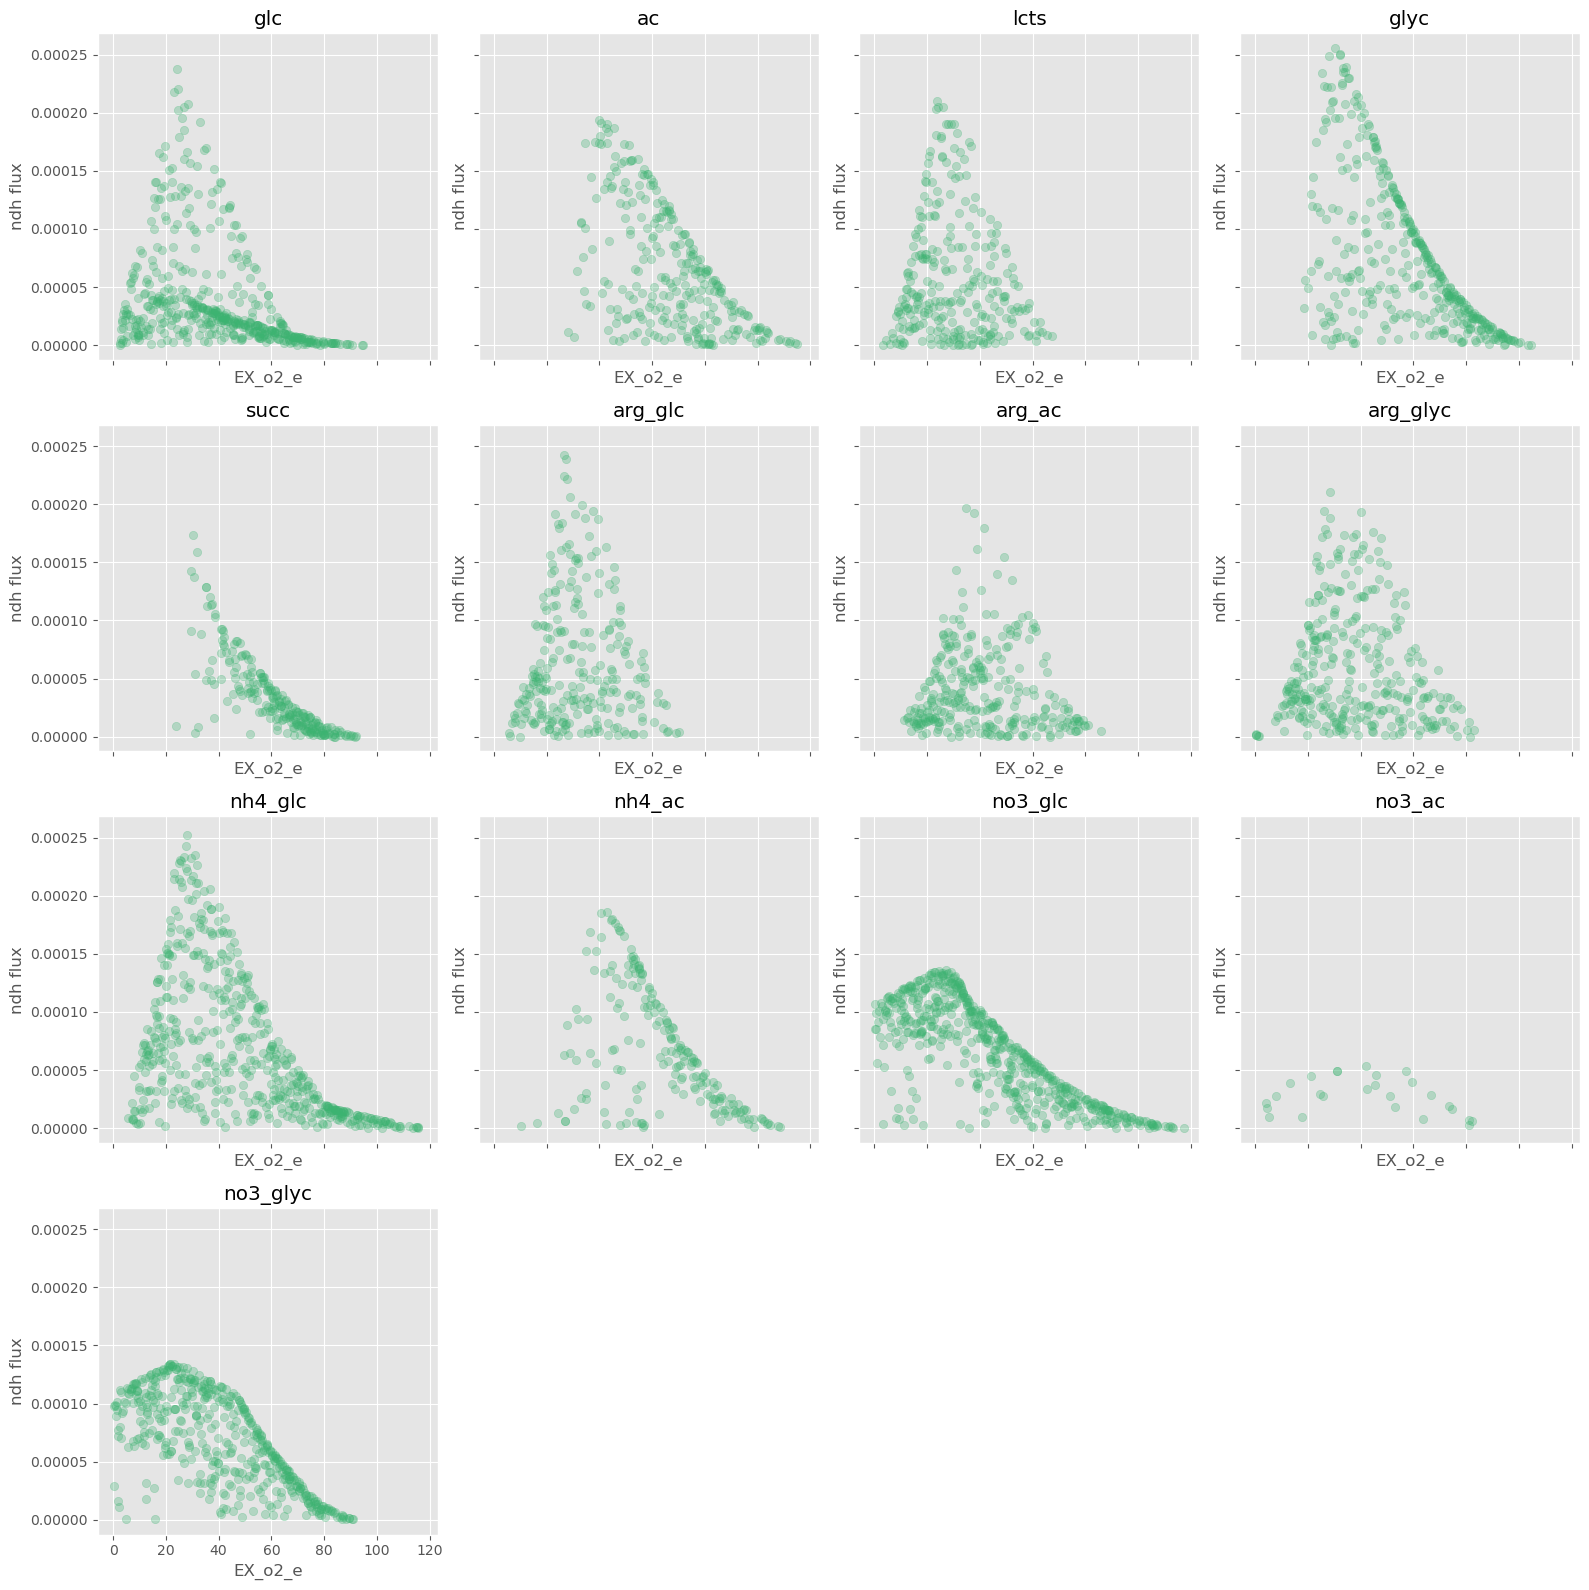

In [201]:
x = -oxygen.iloc[0][active_ndh]
y = ndh.iloc[0][active_ndh]

groups = x.index.to_series().str.split("_sample_").str[0]
envs = groups.unique()

ncols = 4
nrows = math.ceil(len(envs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, env in enumerate(envs):
    ax = axes[i]
    cols = groups[groups == env].index

    ax.scatter(x[cols], y[cols], alpha=0.3, color='mediumseagreen')
    ax.set_title(env)
    ax.set_xlabel("EX_o2_e")
    ax.set_ylabel("ndh flux")

for j in range(len(envs), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle("ndh vs oxygen uptake by environment")
fig.tight_layout()
plt.show()

**fsaB and gldA vs glucose uptake**

In [136]:
glc_rxn = df_clean[df_clean["reaction"] == "EX_glc__D_e"]
glc_active = glc_rxn.loc[:, glc_rxn.columns.str.startswith("glc_sample")].columns.tolist()

In [130]:
glc = df_clean[df_clean['reaction']=='EX_glc__D_e']
fsaB = df_clean[df_clean['reaction']=='translation_b3946']
gldA = df_clean[df_clean['reaction']=='translation_b3945']

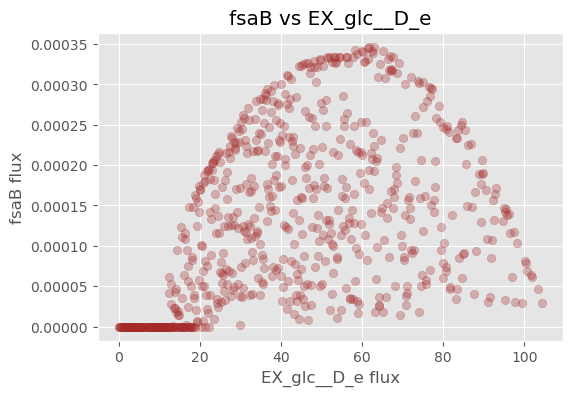

In [144]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], fsaB[glc_active],alpha=0.3, color='brown')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("fsaB flux")
plt.title("fsaB vs EX_glc__D_e")
plt.show()

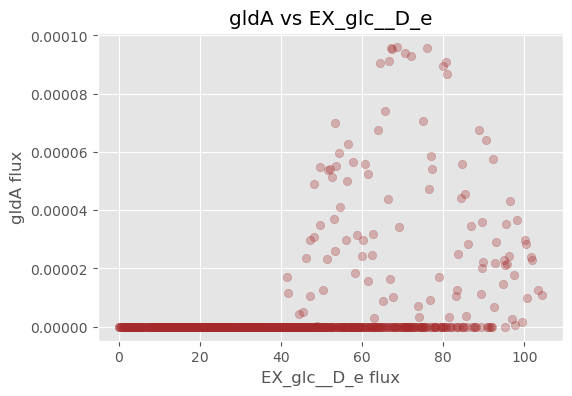

In [145]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], gldA[glc_active],alpha=0.3, color='brown')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("gldA flux")
plt.title("gldA vs EX_glc__D_e")
plt.show()

**decarboxylase vs arginine uptake**

In [150]:
arg_rxn = df_clean[df_clean["reaction"] == "EX_arg__L_e"]
arg_active = arg_rxn.loc[:, arg_rxn.columns.str.startswith("arg_")].columns.tolist()

In [178]:
arg = df_clean[df_clean['reaction']=='EX_arg__L_e']
argdec = df_clean[df_clean['reaction']=='formation_ARGDECARBOXBIO-CPLX_mod_mg2_mod_4:pydx5p']
adi = df_clean[df_clean['reaction']=='translation_b4117']

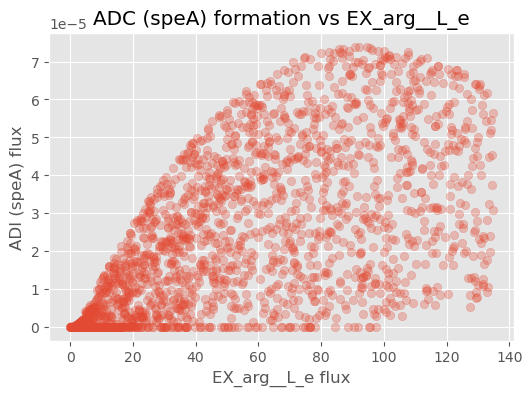

In [203]:
plt.figure(figsize=(6,4))
plt.scatter(-arg[arg_active], argdec[arg_active],alpha=0.3)
plt.xlabel("EX_arg__L_e flux")
plt.ylabel("ADI (speA) flux")
plt.title("ADC (speA) formation vs EX_arg__L_e")
plt.show()

In [189]:
active_speA = activity_binary.columns[activity_binary.loc["translation_b2938"] == 1]

speA = df_clean[df_clean['reaction']=='translation_b2938']

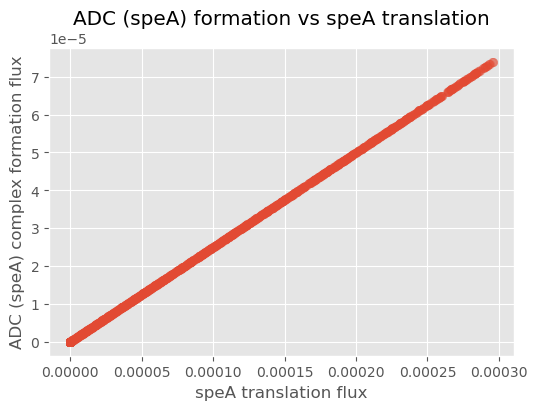

In [204]:
plt.figure(figsize=(6,4))
plt.scatter(speA.drop(columns=cols_drop), argdec.drop(columns=cols_drop),alpha=0.3)
plt.xlabel("speA translation flux")
plt.ylabel("ADC (speA) complex formation flux")
plt.title("ADC (speA) formation vs speA translation")
plt.show()

**Succinate dehydrogenase**

In [182]:
sdh_rxn = df_clean[df_clean["reaction"] == "translation_b0721"]
sdh_active = activity_binary.columns[activity_binary.loc["translation_b0721"] == 1]

sdh = df_clean[df_clean['reaction']=='formation_SUCC-DEHASE_mod_3fe4s_mod_fad_mod_2fe2s_mod_4fe4s']

* **SDH vs oxygen in glc and glyc -> only synthesized in aerobic conditions here?**
    * no, but substrate is limiting

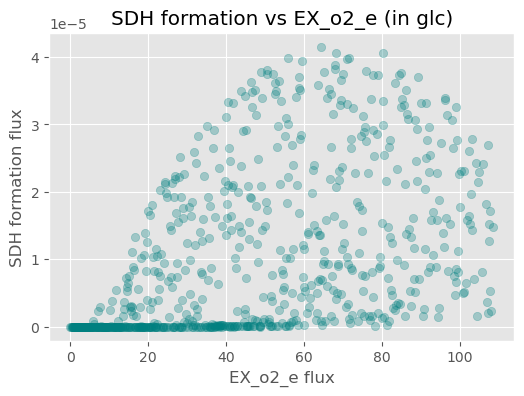

In [205]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen[glc_active], sdh[glc_active],alpha=0.3, color='teal')
plt.xlabel("EX_o2_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_o2_e (in glc)")
plt.show()

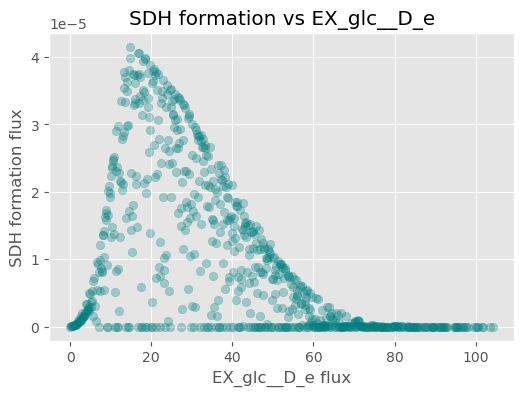

In [206]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], sdh[glc_active],alpha=0.3, color='teal')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_glc__D_e")
plt.show()

In [174]:
glyc_rxn = df_clean[df_clean["reaction"] == "EX_glyc_e"]
glyc_active = glyc_rxn.loc[:, glyc_rxn.columns.str.startswith("glyc_sample")].columns.tolist()

glyc = df_clean[df_clean['reaction']=='EX_glyc_e']

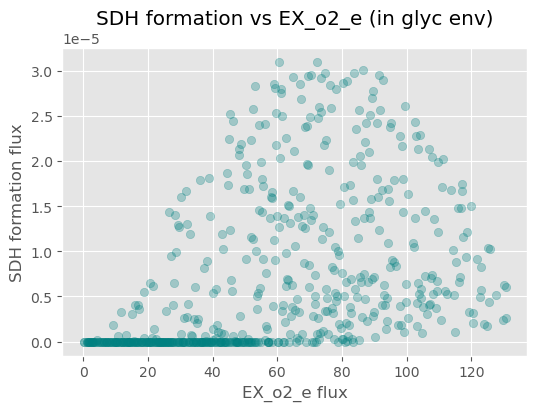

In [207]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen[glyc_active], sdh[glyc_active],alpha=0.3, color='teal')
plt.xlabel("EX_o2_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_o2_e (in glyc env)")
plt.show()

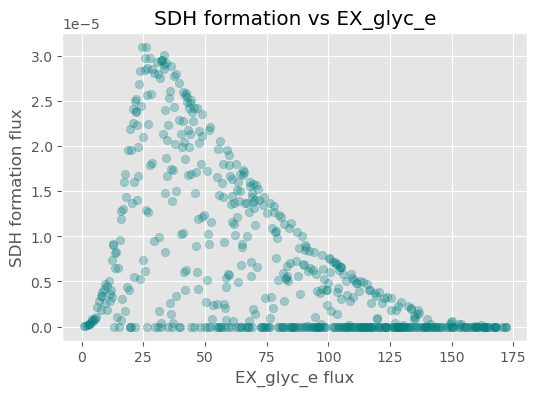

In [208]:
plt.figure(figsize=(6,4))
plt.scatter(-glyc[glyc_active], sdh[glyc_active],alpha=0.3, color='teal')
plt.xlabel("EX_glyc_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_glyc_e")
plt.show()

* **SDH subunits translation vs SDH formation**

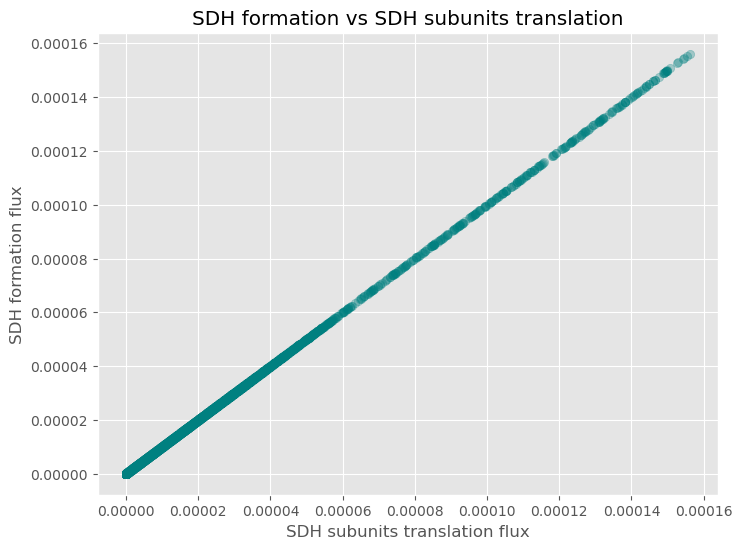

In [209]:
plt.figure(figsize=(8,6))
plt.scatter(sdh_rxn.drop(columns=cols_drop), sdh.drop(columns=cols_drop),alpha=0.3, color='teal')
plt.xlabel("SDH subunits translation flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs SDH subunits translation")
plt.show()

**NapAB complex vs napA-C and nitrate**

In [210]:
no3_rxn = df_clean[df_clean["reaction"] == "EX_no3_e"]
no3_active = no3_rxn.loc[:, no3_rxn.columns.str.startswith("no3_")].columns.tolist()

no3 = df_clean[df_clean['reaction']=='EX_no3_e']

In [214]:
napA_rxn = df_clean[df_clean["reaction"] == "translation_b2206"]
napAB = df_clean[df_clean['reaction']=='formation_NAPAB-CPLX_NAPC-MONOMER_mod_bmocogdp']

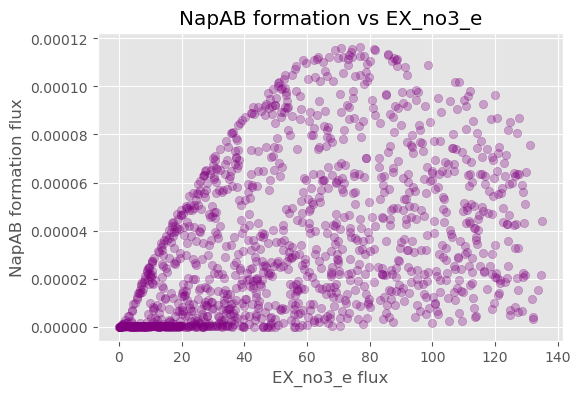

In [215]:
plt.figure(figsize=(6,4))
plt.scatter(-no3[no3_active], napAB[no3_active],alpha=0.3, color='purple')
plt.xlabel("EX_no3_e flux")
plt.ylabel("NapAB formation flux")
plt.title("NapAB formation vs EX_no3_e")
plt.show()

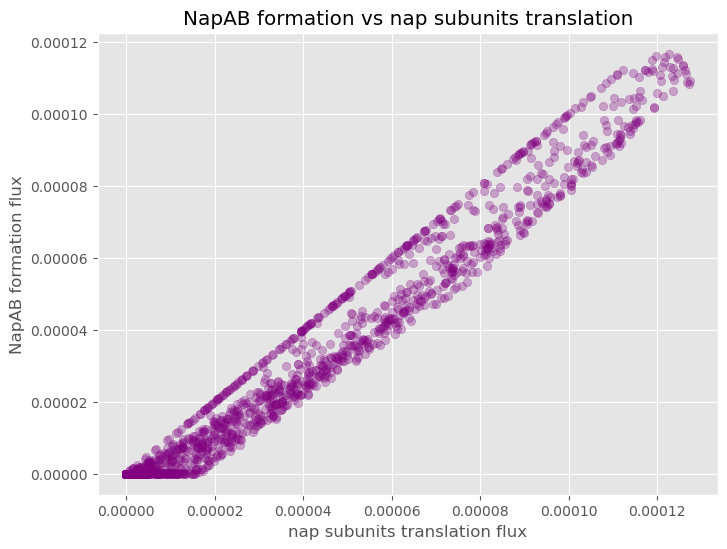

In [220]:
plt.figure(figsize=(8,6))
plt.scatter(napA_rxn.drop(columns=cols_drop), napAB.drop(columns=cols_drop),alpha=0.3, color='purple')
plt.xlabel("nap subunits translation flux")
plt.ylabel("NapAB formation flux")
plt.title("NapAB formation vs nap subunits translation")
plt.show()

```text
translation_b2202
translation_b2203
translation_b2206


```text
de tre blir også transkribert sammen med:
'RNA_b2197', 'RNA_b2198', 'RNA_b2199', 'RNA_b2200', 
'RNA_b2201', 'RNA_b2202', 'RNA_b2203', 'RNA_b2204', 
'RNA_b2205',  'RNA_b2206', , 'RNA_b2207',  

# PCA on raw reaction fluxes 

**interesting rxns**

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [36]:
interesting['biomass_type'].value_counts()

biomass_type
protein             43
prosthetic_group     6
lipid                2
Name: count, dtype: int64

In [37]:
bm= df.set_index('reaction').drop(columns=['biomass_type']).T

In [38]:
interesting_plot = interesting.drop(columns=['biomass_type', 'corr_with_mu', 'variance'])

In [39]:
X = interesting_idx[sample_cols].T
X['source'] = X.index.str.split("_sample_").str[0]

features = X.drop(columns='source')

In [46]:
color_map = sns.color_palette("crest", as_cmap=True)

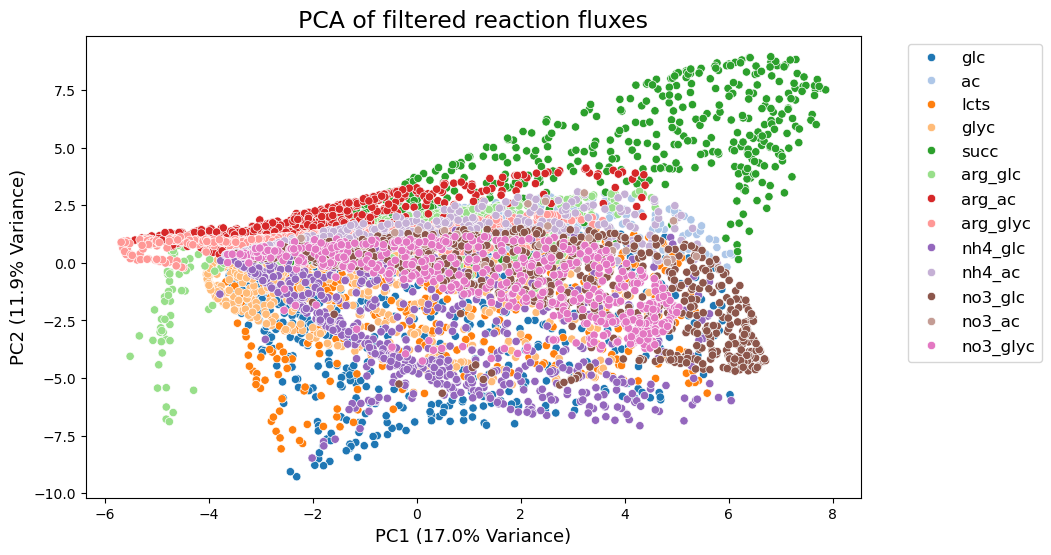

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)
variance =  pca.explained_variance_ratio_


pca_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "biomass_dilution": bm["biomass_dilution"].values,
    "source": X['source']
})

plt.figure(figsize=(10, 6))
# sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)
sc = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    palette="tab20",
    alpha=1.0
)

# cbar = plt.colorbar(sc)
# cbar.set_label(label=r"Growth rate", fontsize=13)
# cbar.ax.tick_params(labelsize=13)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=13)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=13)

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.title('PCA of filtered reaction fluxes', fontsize=17)
plt.show()

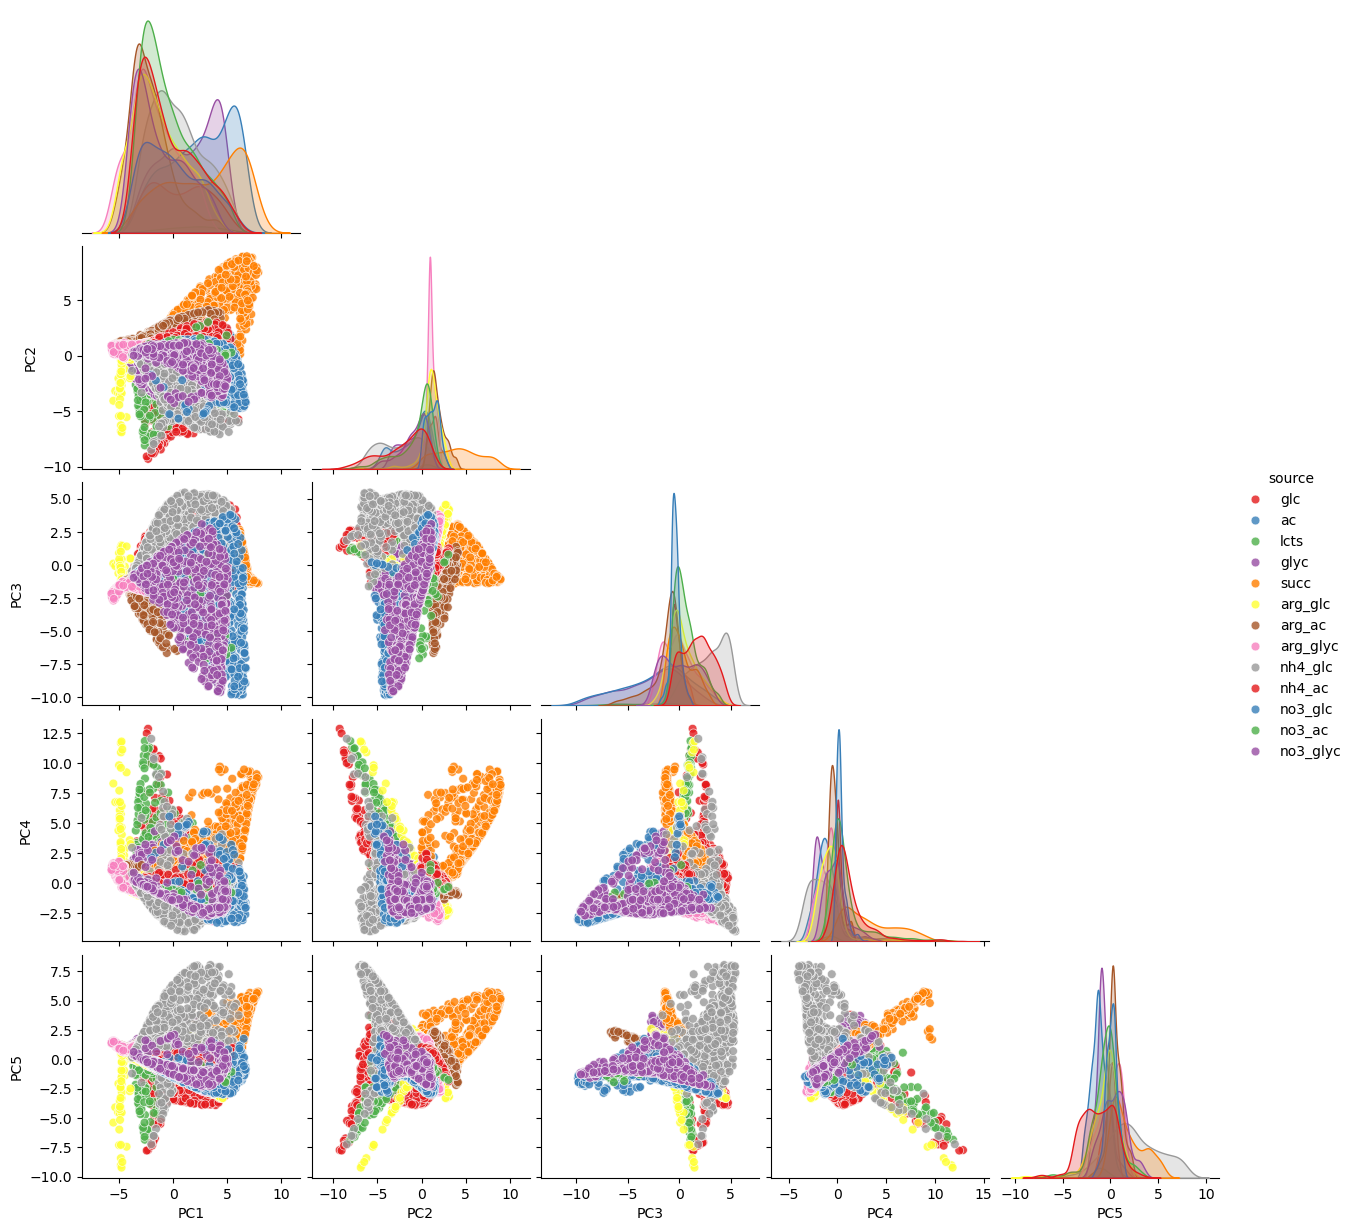

In [68]:
scores_df = pd.DataFrame(
    scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)]
)

# Add metadata for coloring
scores_df["source"] = X["source"].values

sns.pairplot(
    scores_df,
    hue="source",
    palette="Set1",
    corner=True,
    plot_kws={"s": 40, "alpha": 0.8}
)

plt.show()